In [ ]:
# ÉTAPE 1 : CHARGEMENT DES DONNÉES
On importe les deux fichiers Excel dans Python

In [1]:
import pandas as pd   # "pd" est un raccourci qu'on utilisera partout

# Afficher toutes les colonnes sur une seule ligne
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1100)
pd.set_option('display.max_colwidth', 15)

# Chargement du fichier des commandes
df_commandes = pd.read_excel("commande_produit_blanc_2017_2025.xlsx")

# Chargement du fichier des stations
df_stations = pd.read_excel("liste des station.xlsx")

print("Commandes:", df_commandes.shape)
print(df_commandes.head(5))

print("\nStations:", df_stations.shape)
print(df_stations.head(5))

Commandes: (51853, 13)
  Date comptabilisation N° document N° article N° origine N° contact origine  Quantité facturée  Montant vente (réel)  Coût total (réel) Code Produit Type écriture   Type document Code magasin N° commande
0      2017-02-03          BL170352      A0001      C0437             NaN            -4000.0          1591724.0            -1420103.0      PROD-BLANC         Vente  Expédition ...         ORYX         NaN
1      2017-02-03          BL170352      A0002      C0437             NaN            -4000.0          1568818.0                   0.0      PROD-BLANC         Vente  Expédition ...         ORYX         NaN
2      2017-02-03          BL170353      A0001      C0001             NaN            -3000.0          1202793.0            -1065077.0      PROD-BLANC         Vente  Expédition ...         ORYX         NaN
3      2017-02-03          BL170353      A0002      C0001             NaN           -30000.0         11856138.0                   0.0      PROD-BLANC        

Le fichier commandes contient **51 853 lignes et le fichier stations 147 stations**.

In [ ]:
## ÉTAPE 2 : FUSION DES DEUX FICHIERS
# On relie les commandes aux stations via le code client. Colonne clé : "N° origine" (commandes) = "Code Contact Client" (stations)

In [2]:
df = pd.merge(
    df_commandes,                            # fichier principal : les commandes
    df_stations,                             # fichier secondaire : les stations
    left_on="N° contact origine",            # colonne de jointure dans commandes
    right_on="Code_sous_compte_Client",      # colonne de jointure dans stations
    how="left"                               # on garde TOUTES les commandes
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 15)

print("Nombre de lignes après fusion :", df.shape[0])
print("Nombre de colonnes après fusion :", df.shape[1])
print()
print(df[["Date comptabilisation", "N° contact origine", "NOM CLIENT", 
          "Code Station", "Quantité facturée"]].head(5))

Nombre de lignes après fusion : 51853
Nombre de colonnes après fusion : 21

  Date comptabilisation N° contact origine NOM CLIENT Code Station  Quantité facturée
0      2017-02-03                   NaN           NaN          NaN         -4000.0   
1      2017-02-03                   NaN           NaN          NaN         -4000.0   
2      2017-02-03                   NaN           NaN          NaN         -3000.0   
3      2017-02-03                   NaN           NaN          NaN        -30000.0   
4      2017-02-03                   NaN           NaN          NaN         -4000.0   


# ÉTAPE 3 : NETTOYAGE DES DONNÉES
Avant toute analyse, on vérifie et corrige la qualité des données

In [5]:
# --- 3.1 Convertir la date en format datetime ---
df["Date comptabilisation"] = pd.to_datetime(df["Date comptabilisation"])

# --- 3.2 Vérifier les valeurs manquantes ---
print("=== Valeurs manquantes par colonne ===")
print(df.isnull().sum())
print()

# --- 3.3 Garder uniquement les commandes avec une station identifiée ---
df_clean = df.dropna(subset=["Code Station"]).copy()  # .copy() évite le warning
print("Lignes avant nettoyage :", df.shape[0])
print("Lignes après nettoyage :", df_clean.shape[0])
print("Lignes supprimées :", df.shape[0] - df_clean.shape[0])
print()

# --- 3.4 Corriger les quantités négatives ---
df_clean["Quantité facturée"] = df_clean["Quantité facturée"].abs()

print("=== Vérification des quantités après correction ===")
print(df_clean["Quantité facturée"].describe())

=== Valeurs manquantes par colonne ===
Date comptabilisation          0
N° document                    0
N° article                     0
N° origine                     0
N° contact origine         12169
Quantité facturée              0
Montant vente (réel)           0
Coût total (réel)              0
Code Produit                   0
Type écriture                  0
Type document                  0
Code magasin                   0
N° commande                 8465
Code Contact Client        17703
NOM CLIENT                 17703
Code_sous_compte_Client    17703
Nom sous compte            17703
TYPE                       17703
STATUT                     17703
Code Station               17703
GROUPE TYPE                17703
dtype: int64

Lignes avant nettoyage : 51853
Lignes après nettoyage : 34150
Lignes supprimées : 17703

=== Vérification des quantités après correction ===
count    34150.000000
mean      7977.507116
std       6100.131202
min          8.000000
25%       4000.000000
50%

In [ ]:
# ÉTAPE 4 : SUPPRESSION DES COLONNES INUTILES
On garde uniquement les colonnes utiles pour la prédiction

In [7]:
colonnes_a_supprimer = [
    "N° document",
    "Montant vente (réel)",
    "Coût total (réel)",
    "Type écriture",
    "Code magasin",
    "Code_sous_compte_Client",
    "Code Contact Client",
    "N° commande"
]

df_clean = df_clean.drop(columns=colonnes_a_supprimer, errors="ignore")

# Vérification des colonnes restantes
print("Colonnes restantes :")
for col in df_clean.columns:
    print(" -", col)

print()
print("Dimensions finales :", df_clean.shape)
print()

Colonnes restantes :
 - Date comptabilisation
 - N° article
 - N° origine
 - N° contact origine
 - Quantité facturée
 - Code Produit
 - Type document
 - NOM CLIENT
 - Nom sous compte
 - TYPE
 - STATUT
 - Code Station
 - GROUPE TYPE

Dimensions finales : (34150, 13)



In [9]:
# Afficher les 5 premières lignes en réinitialisant l'index
df_clean = df_clean.reset_index(drop=True)
df_clean.head()

,Date comptabilisation,N° article,N° origine,N° contact origine,Quantité facturée,Code Produit,Type document,NOM CLIENT,Nom sous compte,TYPE,STATUT,Code Station,GROUPE TYPE
0,2020-01-13,A0001,C1234,CC2616,5000.0,PROD-BLANC,Expédition ...,GIBLAND COM...,STATION ATTAKE,CODO,Fonctionnelle,ST0049,STATION
1,2020-01-13,A0002,C1234,CC2616,4000.0,PROD-BLANC,Expédition ...,GIBLAND COM...,STATION ATTAKE,CODO,Fonctionnelle,ST0049,STATION
2,2020-01-13,A0001,C1249,CC2650,1000.0,PROD-BLANC,Expédition ...,TONI ET FILS,STATION NDALI,DODO,Fonctionnelle,ST0092,STATION
3,2020-01-13,A0002,C1249,CC2650,16000.0,PROD-BLANC,Expédition ...,TONI ET FILS,STATION NDALI,DODO,Fonctionnelle,ST0092,STATION
4,2020-01-13,A0001,C1233,CC2614,5000.0,PROD-BLANC,Expédition ...,AYODELE BUS...,STATION OUIDAH,CODO,Fonctionnelle,ST0016,STATION


# ÉTAPE 5 : Feature Engineering

### 5-1 AJOUT DES COLONNES DE TEMPS
On extrait le jour, le mois, l'année, le trimestre; jour de la semaine et les weekend depuis la date

In [11]:
df_clean['Jour'] = df_clean['Date comptabilisation'].dt.day
df_clean["Mois"] = df_clean["Date comptabilisation"].dt.month
df_clean["Année"] = df_clean["Date comptabilisation"].dt.year
df_clean["Trimestre"] = df_clean["Date comptabilisation"].dt.quarter
df_clean['JourSemaine'] = df_clean['Date comptabilisation'].dt.dayofweek
df_clean['Weekend'] = df_clean['JourSemaine'].isin([5,6]).astype(int)

#print("Colonnes ajoutées : Année, Mois, Trimestre")
df_clean.head()

,Date comptabilisation,N° article,N° origine,N° contact origine,Quantité facturée,Code Produit,Type document,NOM CLIENT,Nom sous compte,TYPE,STATUT,Code Station,GROUPE TYPE,Jour,Mois,Année,Trimestre,JourSemaine,Weekend
0,2020-01-13,A0001,C1234,CC2616,5000.0,PROD-BLANC,Expédition ...,GIBLAND COM...,STATION ATTAKE,CODO,Fonctionnelle,ST0049,STATION,13,1,2020,1,0,0
1,2020-01-13,A0002,C1234,CC2616,4000.0,PROD-BLANC,Expédition ...,GIBLAND COM...,STATION ATTAKE,CODO,Fonctionnelle,ST0049,STATION,13,1,2020,1,0,0
2,2020-01-13,A0001,C1249,CC2650,1000.0,PROD-BLANC,Expédition ...,TONI ET FILS,STATION NDALI,DODO,Fonctionnelle,ST0092,STATION,13,1,2020,1,0,0
3,2020-01-13,A0002,C1249,CC2650,16000.0,PROD-BLANC,Expédition ...,TONI ET FILS,STATION NDALI,DODO,Fonctionnelle,ST0092,STATION,13,1,2020,1,0,0
4,2020-01-13,A0001,C1233,CC2614,5000.0,PROD-BLANC,Expédition ...,AYODELE BUS...,STATION OUIDAH,CODO,Fonctionnelle,ST0016,STATION,13,1,2020,1,0,0


### 5-2 Lag Features
Quantité précédente

In [18]:
df_clean = df_clean.sort_values(['Code Station', 'Date comptabilisation'])

df_clean['Lag_1'] = df_clean.groupby('Code Station')['Quantité facturée'].shift(1)
df_clean

,Date comptabilisation,N° article,N° origine,N° contact origine,Quantité facturée,Code Produit,Type document,NOM CLIENT,Nom sous compte,TYPE,STATUT,Code Station,GROUPE TYPE,Jour,Mois,Année,Trimestre,JourSemaine,Weekend,Lag_1
13322,2022-09-27,A0001,C0083,CC6471,20000.0,PROD-BLANC,Expédition ...,2M ASSOCIES,STATION BOU...,CODO,Fonctionnelle,ST0001,STATION,27,9,2022,3,1,0,NaN
13323,2022-09-27,A0002,C0083,CC6471,15000.0,PROD-BLANC,Expédition ...,2M ASSOCIES,STATION BOU...,CODO,Fonctionnelle,ST0001,STATION,27,9,2022,3,1,0,20000.0
13637,2022-10-17,A0001,C0083,CC6471,8000.0,PROD-BLANC,Expédition ...,2M ASSOCIES,STATION BOU...,CODO,Fonctionnelle,ST0001,STATION,17,10,2022,4,0,0,15000.0
13648,2022-10-17,A0002,C0083,CC6471,10000.0,PROD-BLANC,Expédition ...,2M ASSOCIES,STATION BOU...,CODO,Fonctionnelle,ST0001,STATION,17,10,2022,4,0,0,8000.0
13727,2022-10-20,A0002,C0083,CC6471,8000.0,PROD-BLANC,Expédition ...,2M ASSOCIES,STATION BOU...,CODO,Fonctionnelle,ST0001,STATION,20,10,2022,4,3,0,10000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33763,2025-12-15,A0001,C2982,CC8008,13000.0,PROD-BLANC,Expédition ...,YEL AFRIQUE,STATION TANKPÊ,DODO,Fonctionnelle,ST0095,STATION,15,12,2025,4,0,0,10000.0
33791,2025-12-16,A0002,C2982,CC8008,5000.0,PROD-BLANC,Expédition ...,YEL AFRIQUE,STATION TANKPÊ,DODO,Fonctionnelle,ST0095,STATION,16,12,2025,4,1,0,13000.0
33965,2025-12-24,A0001,C2982,CC8008,10000.0,PROD-BLANC,Expédition ...,YEL AFRIQUE,STATION TANKPÊ,DODO,Fonctionnelle,ST0095,STATION,24,12,2025,4,2,0,5000.0
33993,2025-12-24,A0001,C2982,CC8008,4000.0,PROD-BLANC,Expédition ...,YEL AFRIQUE,STATION TANKPÊ,DODO,Fonctionnelle,ST0095,STATION,24,12,2025,4,2,0,10000.0


### 5-3 Moyenne mobile

In [25]:
df_clean['Moyenne_7j'] = (
    df_clean.groupby('Code Station')['Quantité facturée']
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

df_clean

,Date comptabilisation,N° article,N° origine,N° contact origine,Quantité facturée,Code Produit,Type document,NOM CLIENT,Nom sous compte,TYPE,STATUT,Code Station,GROUPE TYPE,Jour,Mois,Année,Trimestre,JourSemaine,Weekend,Lag_1,Moyenne_7j
13322,2022-09-27,A0001,C0083,CC6471,20000.0,PROD-BLANC,Expédition ...,2M ASSOCIES,STATION BOU...,CODO,Fonctionnelle,ST0001,STATION,27,9,2022,3,1,0,NaN,20000.000000
13323,2022-09-27,A0002,C0083,CC6471,15000.0,PROD-BLANC,Expédition ...,2M ASSOCIES,STATION BOU...,CODO,Fonctionnelle,ST0001,STATION,27,9,2022,3,1,0,20000.0,17500.000000
13637,2022-10-17,A0001,C0083,CC6471,8000.0,PROD-BLANC,Expédition ...,2M ASSOCIES,STATION BOU...,CODO,Fonctionnelle,ST0001,STATION,17,10,2022,4,0,0,15000.0,14333.333333
13648,2022-10-17,A0002,C0083,CC6471,10000.0,PROD-BLANC,Expédition ...,2M ASSOCIES,STATION BOU...,CODO,Fonctionnelle,ST0001,STATION,17,10,2022,4,0,0,8000.0,13250.000000
13727,2022-10-20,A0002,C0083,CC6471,8000.0,PROD-BLANC,Expédition ...,2M ASSOCIES,STATION BOU...,CODO,Fonctionnelle,ST0001,STATION,20,10,2022,4,3,0,10000.0,12200.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33763,2025-12-15,A0001,C2982,CC8008,13000.0,PROD-BLANC,Expédition ...,YEL AFRIQUE,STATION TANKPÊ,DODO,Fonctionnelle,ST0095,STATION,15,12,2025,4,0,0,10000.0,8285.714286
33791,2025-12-16,A0002,C2982,CC8008,5000.0,PROD-BLANC,Expédition ...,YEL AFRIQUE,STATION TANKPÊ,DODO,Fonctionnelle,ST0095,STATION,16,12,2025,4,1,0,13000.0,7142.857143
33965,2025-12-24,A0001,C2982,CC8008,10000.0,PROD-BLANC,Expédition ...,YEL AFRIQUE,STATION TANKPÊ,DODO,Fonctionnelle,ST0095,STATION,24,12,2025,4,2,0,5000.0,7857.142857
33993,2025-12-24,A0001,C2982,CC8008,4000.0,PROD-BLANC,Expédition ...,YEL AFRIQUE,STATION TANKPÊ,DODO,Fonctionnelle,ST0095,STATION,24,12,2025,4,2,0,10000.0,7000.000000


## ÉTAPE 6 : ANALYSE EXPLORATOIRE

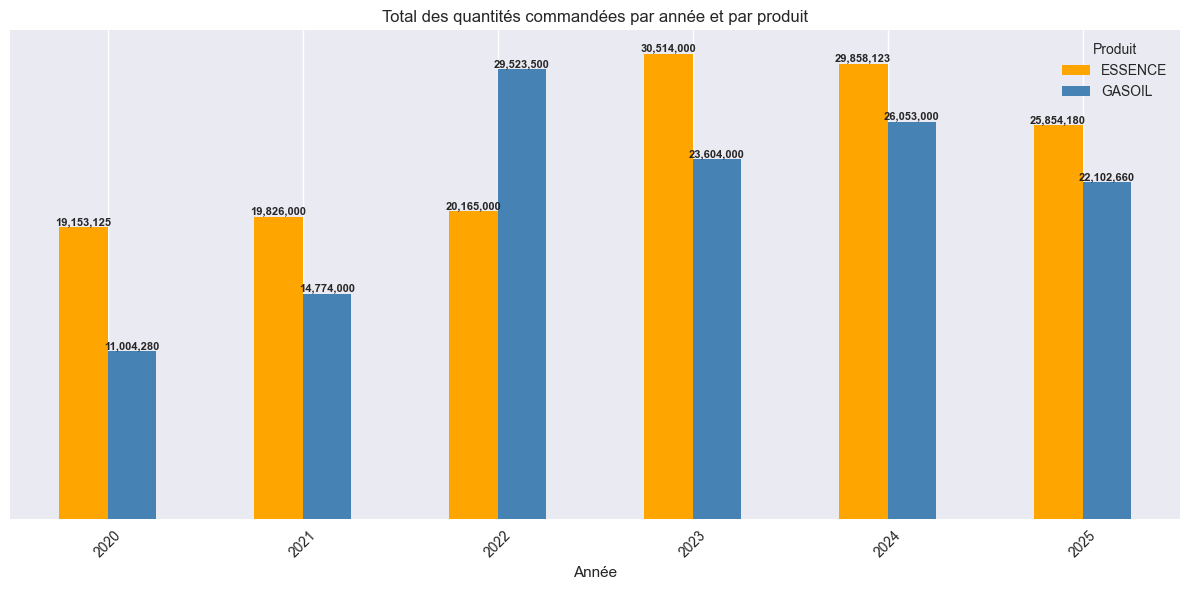

In [19]:
# ÉTAPE 6.1 : COMMANDES PAR ANNÉE ET PAR PRODUIT
# A0001 = ESSENCE / A0002 = GASOIL

import matplotlib.pyplot as plt

# Renommer les produits pour plus de clarté
df_clean["Produit"] = df_clean["N° article"].map({
    "A0001": "ESSENCE",
    "A0002": "GASOIL"
})

# Grouper par année et produit
commandes_par_an_produit = df_clean.groupby(["Année", "Produit"])["Quantité facturée"].sum().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
commandes_par_an_produit.plot(kind="bar", ax=ax, color=["orange", "steelblue"])

# Etiquettes au dessus de chaque barre
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=8, fontweight='bold'
    )

plt.title("Total des quantités commandées par année et par produit")
plt.xlabel("Année")
ax.yaxis.set_visible(False)
plt.xticks(rotation=45)
plt.legend(title="Produit")
plt.tight_layout()
plt.show()

## Interprétation - Quantités commandées par année et par produit

**ESSENCE (orange) - Produit dominant :**
L'essence représente la majorité des commandes chaque année. Elle progresse de **19 153 125** en **2020** à un pic de **30 514 000** en **2023**, puis redescend légèrement à **25 854 180** en **2025**.

**GASOIL (bleu) - Croissance plus forte :**
Le gasoil part de **11 004 280** en **2020** et monte jusqu'à **29 523 500** en **2022**, soit une croissance de **+168%** en 2 ans. C'est le produit qui a connu la plus forte progression.

**2020 - Écart important entre les deux produits :**
L'essence représente presque le **double** du gasoil, reflétant probablement l'impact du **COVID-19**.

**2022 — Forte hausse du gasoil :**
Le gasoil enregistre une augmentation significative de **+168%** par rapport à 2020. Cette hausse peut s'expliquer par **l'augmentation des activités de transport et de commerce** au Bénin, ou par **l'entrée de nouvelles stations** dans le réseau de distribution.

**2023-2024 - L'essence reprend la tête :**
L'essence redevient dominante avec **30 514 000** en **2023** et **29 858 123** en **2024**.

**2025 — Baisse des commandes :**
Les quantités commandées reculent à **47 956 840**, soit une baisse de **-14%** par rapport au pic de **2024**. Cette tendance baissière mérite une attention particulière et pourrait faire l'objet d'une analyse approfondie pour en identifier les causes.

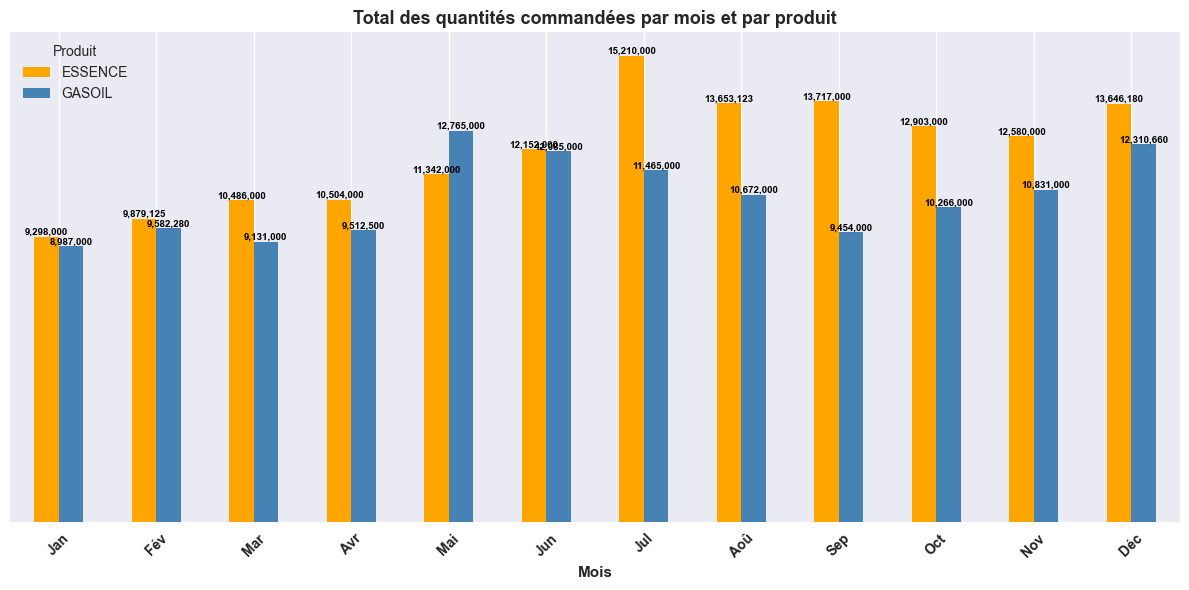

In [25]:
# --- 6.2 Commandes par mois et par produit ---
commandes_par_mois_produit = df_clean.groupby(["Mois", "Produit"])["Quantité facturée"].sum().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
commandes_par_mois_produit.plot(kind="bar", ax=ax, color=["orange", "steelblue"])

# Etiquettes en gras au dessus de chaque barre
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=7, fontweight='bold',
        color='black'
    )

plt.title("Total des quantités commandées par mois et par produit", 
          fontsize=13, fontweight='bold')
plt.xlabel("Mois", fontweight='bold')
ax.yaxis.set_visible(False)
plt.xticks(ticks=range(12),
           labels=["Jan","Fév","Mar","Avr","Mai","Jun",
                   "Jul","Aoû","Sep","Oct","Nov","Déc"],
           rotation=45, fontweight='bold')
plt.legend(title="Produit", title_fontsize=10)
plt.tight_layout()
plt.show()

## Interprétation — Quantités commandées par mois et par produit

**ESSENCE (orange) — Dominante toute l'année :**
L'essence dépasse le gasoil chaque mois sans exception. Elle atteint son **pic en juillet** avec **15 210 000**, ce qui correspond probablement à la période des grandes vacances et à l'augmentation des déplacements.

**GASOIL (bleu) — Plus stable :**
Le gasoil reste relativement stable autour de **9 000 000 à 12 000 000** par mois avec moins de variations que l'essence.

**Juillet — Mois record pour l'essence :**
Avec **15 210 000**, juillet est le mois le plus élevé de l'année pour l'essence, soit **+64%** par rapport au mois le plus bas (janvier avec **9 298 000**).

**Janvier-Mars — Période creuse :**
Les deux produits enregistrent leurs plus faibles valeurs en début d'année, correspondant à une période de faible activité économique après les fêtes de fin d'année.

**Mai-Juillet — Période de forte demande :**
On observe une montée progressive des commandes de mai à juillet pour les deux produits.

**Août-Décembre — Légère baisse puis stabilisation :**
Après le pic de juillet, les commandes redescendent progressivement jusqu'en fin d'année.

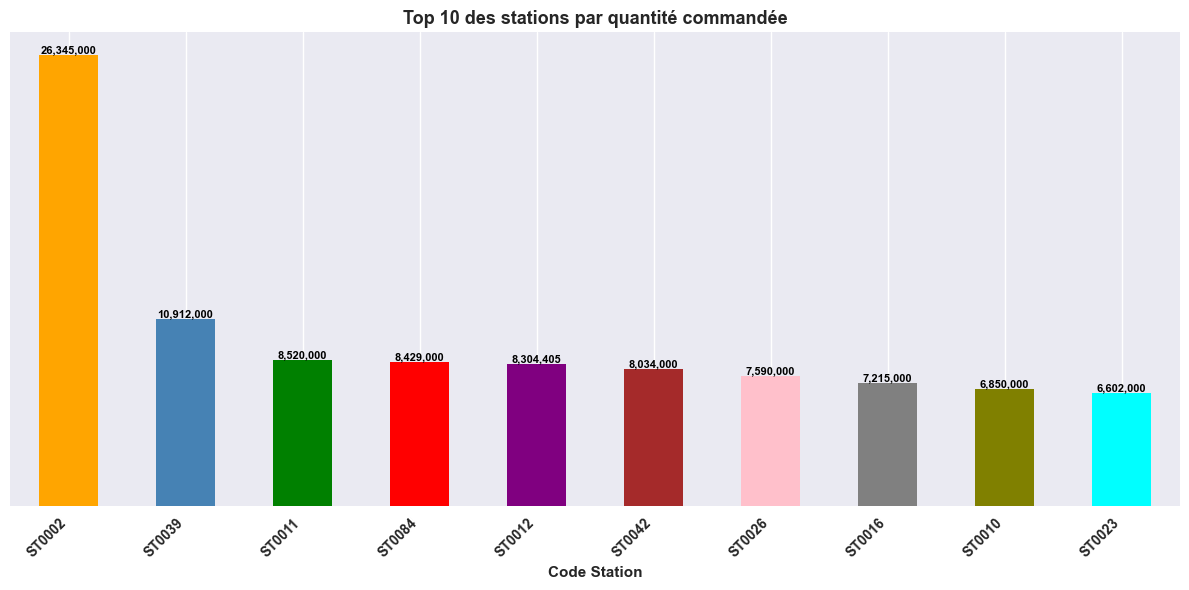

In [31]:
# --- 6.3 Top 10 des stations par quantité commandée ---
top10_stations = df_clean.groupby("Code Station")["Quantité facturée"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
top10_stations.plot(kind="bar", ax=ax, color=["orange", "steelblue", "green",
                                               "red", "purple", "brown",
                                               "pink", "gray", "olive", "cyan"])

# Etiquettes en gras au dessus de chaque barre
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom',
        fontsize=8, fontweight='bold',
        color='black'
    )

plt.title("Top 10 des stations par quantité commandée",
          fontsize=13, fontweight='bold')
plt.xlabel("Code Station", fontweight='bold')
ax.yaxis.set_visible(False)
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.tight_layout()
plt.show()

## Interprétation — Top 10 des stations par quantité commandée

**ST0002 — Station largement dominante :**
Avec **26 345 000** unités commandées, ST0002 se détache très nettement de toutes les autres stations. Elle représente à elle seule presque le **double** de la deuxième station (ST0039 avec **10 912 000**). C'est clairement la station la plus stratégique du réseau.

**ST0039 — Deuxième position solide :**
Avec **10 912 000**, ST0039 occupe la deuxième place mais reste loin derrière ST0002, avec un écart de **-59%**.

**ST0011, ST0084, ST0012, ST0042 — Groupe intermédiaire :**
Ces quatre stations se situent dans une fourchette serrée entre **8 034 000** et **8 520 000**, montrant un niveau d'activité similaire.

**ST0026, ST0016, ST0010, ST0023 — Groupe inférieur :**
Ces stations ferment le top 10 avec des valeurs entre **6 602 000** et **7 590 000**.

**Concentration de l'activité :**
ST0002 et ST0039 concentrent à elles deux une part très importante des commandes, ce qui représente un **risque de dépendance** pour le réseau.

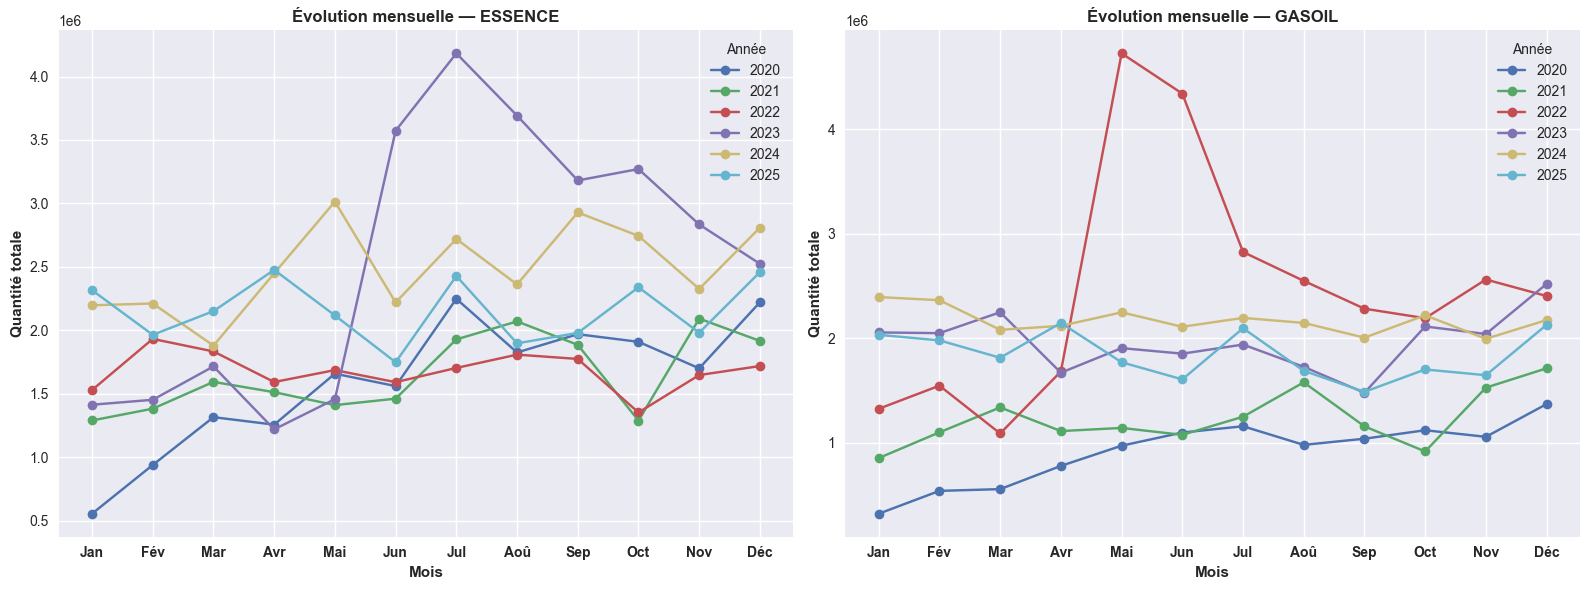

In [33]:
# --- 6.4 Évolution mensuelle des commandes par année et par produit (courbe) ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, produit in enumerate(["ESSENCE", "GASOIL"]):
    df_produit = df_clean[df_clean["Produit"] == produit]
    commandes_mois_annee = df_produit.groupby(["Année", "Mois"])["Quantité facturée"].sum().reset_index()

    for annee in commandes_mois_annee["Année"].unique():
        data = commandes_mois_annee[commandes_mois_annee["Année"] == annee]
        axes[idx].plot(data["Mois"], data["Quantité facturée"], marker='o', label=str(annee))

    axes[idx].set_title(f"Évolution mensuelle — {produit}", 
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Mois", fontweight='bold')
    axes[idx].set_ylabel("Quantité totale", fontweight='bold')
    axes[idx].set_xticks(range(1, 13))
    axes[idx].set_xticklabels(["Jan","Fév","Mar","Avr","Mai","Jun",
                                "Jul","Aoû","Sep","Oct","Nov","Déc"],
                               fontweight='bold')
    axes[idx].legend(title="Année")

plt.tight_layout()
plt.show()

## Interprétation — Évolution mensuelle des commandes par année et par produit

### ESSENCE
**2023 — Année exceptionnelle :**
La courbe de **2023** (violet) domine nettement toutes les autres années avec un pic spectaculaire en **juillet** dépassant **4 000 000**. C'est l'année la plus performante pour l'essence.

**Pic de juillet récurrent :**
Presque toutes les années montrent une **hausse en juillet**, confirmant une saisonnalité forte sur ce mois pour l'essence.

**2020 — Année la plus faible :**
La courbe de **2020** (bleu) reste en dessous de toutes les autres, avec un démarrage très bas en janvier à **500 000**.

### GASOIL
**2022 — Année atypique :**
La courbe de **2022** (rouge) présente un pic très inhabituel en **mai-juin** dépassant **4 500 000**, très au-dessus des autres années. Cela mérite une investigation approfondie.

**2020 — Année la plus faible :**
Comme pour l'essence, **2020** enregistre les valeurs les plus basses tout au long de l'année.

**Stabilité relative :**
Contrairement à l'essence, le gasoil montre des courbes plus **resserrées** entre 2021 et 2025, indiquant une demande plus stable.

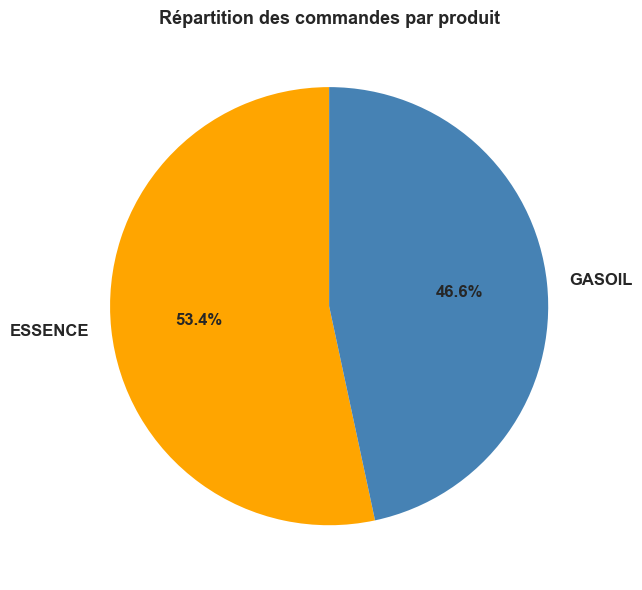

In [34]:
# --- 6.5 Répartition des commandes par produit (camembert) ---
repartition_produit = df_clean.groupby("Produit")["Quantité facturée"].sum()

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(
    repartition_produit,
    labels=repartition_produit.index,
    autopct='%1.1f%%',
    colors=["orange", "steelblue"],
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title("Répartition des commandes par produit", 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Interprétation — Répartition des commandes par produit

**ESSENCE — Produit majoritaire :**
L'essence représente **53.4%** des commandes totales, soit légèrement plus de la moitié du volume global commandé par les stations.

**GASOIL — Produit minoritaire mais significatif :**
Le gasoil représente **46.6%** des commandes, une part très proche de l'essence. Cela montre que les deux produits ont une importance quasi **équivalente** dans l'activité globale du réseau.

**Équilibre entre les deux produits :**
L'écart entre l'essence et le gasoil est faible (**6.8 points**), ce qui indique que le réseau de stations dessert aussi bien les véhicules à essence que les véhicules diesel. Aucun des deux produits ne domine largement l'autre, ce qui traduit une **demande diversifiée** et un portefeuille de clients équilibré.
``

## 7. Préparation des données Machine Learning

### 7-1 Encodage des variables catégorielles

### 7-2 Variables explicatives et cible

### 7-3 Suppression des valeurs manquantes créées par les lags

## 8. Séparation Train/Test

## 9. Construction du modèle

### 9-1 Random Forest (LM)

#### 9-1.1 Prédictions

#### 9-1.2 Évaluation du modèle

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions_rf)
rmse = mean_squared_error(y_test, predictions_rf) ** 0.5
r2 = r2_score(y_test, predictions_rf)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

### 9-2 XGBoost (ML)

#### 9-2.1 Prédictions

#### 9-2.2 Évaluation du modèle

## 10. Modèle ARIMA ( Séries Temporelles)
##### Principe

ARIMA est un modèle statistique de prévision temporelle.

Il fonctionne bien lorsque :

les données suivent une tendance temporelle ;
les historiques sont réguliers ;
les comportements sont relativement stables.

##### Installation
pip install statsmodels

### 10.1 Préparation des données ARIMA

### 10.2 Vérification graphique

### 10.3 Construction du modèle ARIMA

### 10.4 Prédictions ARIMA

### 10.4 Visualisation des prévisions

## 11. Modèle Prophet
##### Principe

Prophet est un modèle développé par entity["company","Meta Platforms"].

Il est très efficace pour :

les séries temporelles ;
les tendances saisonnières ;
les effets calendaires.

##### Installation
pip install prophet

### 11.1 Préparation des données Prophet

Prophet exige deux colonnes :

Colonne	Signification  
ds	date  
y	valeur à prédire

In [ ]:
#Transformation du dataset



### 11.2 Construction du modèle Prophet

### 11.3 Génération des dates futures

### 11.4 Prévisions Prophet

### 11.5 Visualisation des prévisions Prophet

### 11.6 Composantes de la prévision